# Early Failure Prediction — Transformer (RSS 2023)

> Montané-Güell, Watson, Correll. *Early Failure Prediction During Robotic Assembly Using Transformers.*

**핵심 아이디어**: F/T 센서 6채널 시계열(Fx, Fy, Fz, Tx, Ty, Tz)을 Transformer에 입력하여  
삽입 초반에 실패를 예측 → preemptive restart → makespan 최대 60% 단축

| 비교 | Reactive | FCN+Preemptive | **Transformer+Preemptive** |
|------|----------|---------------|---------------------------|
| 평균 Makespan | 104.97s | 66.97s | **41.25s** |
| 예측 시점 | — | 기준 | **3× 빠름** |
| 모델 파라미터 | — | — | ~68K |

In [1]:
# ── 0. Setup ──────────────────────────────────────────────────────────────────
import sys
import json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from pathlib import Path
from reproducibility import make_generator, seed_everything, seed_worker

DATA_DIR = (Path.cwd() / '../../aic_data').resolve()
assert DATA_DIR.exists(), f"data 폴더를 찾지 못했습니다: {DATA_DIR}"
print(f"DATA_DIR: {DATA_DIR}")

plt.style.use('seaborn-v0_8-whitegrid')

CFG = {
    'SEED' : 42
}

seed_everything(CFG['SEED'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')

DATA_DIR: /home/swlinux/aic_sejong/aic_data
Device : cuda
PyTorch: 2.11.0+cu130


## 1. 데이터 로딩

각 에피소드 디렉토리 구조:
```
YYYYMMDD_HHMMSS_<task>/
  steps.jsonl          ← 스텝별 F/T 센서 데이터
  episode_summary.json ← 성공/실패 레이블
```

- **입력**: `insert` 페이즈의 `wrist_wrench` → (T, 6) 시계열
- **레이블**: `insertion_event_observed` → 1=성공, 0=실패

In [2]:
# ── 1-1. 실제 에피소드 로딩 함수 ───────────────────────────────────────────────
FEATURE_NAMES = ['Fx', 'Fy', 'Fz', 'Tx', 'Ty', 'Tz']

def load_episode(ep_dir: Path):
    """steps.jsonl → (T, 6) F/T 시계열 + 레이블 반환."""
    ep_dir = Path(ep_dir)
    summary_path = ep_dir / 'episode_summary.json'
    steps_path   = ep_dir / 'steps.jsonl'
    if not summary_path.exists() or not steps_path.exists():
        return None, None

    with open(summary_path) as f:
        summary = json.load(f)
    label = 1 if summary.get('insertion_event_observed', True) else 0  # 1=성공

    rows = []
    with open(steps_path) as f:
        for line in f:
            s = json.loads(line)
            if s['phase'] != 'insert':
                continue
            w = s['observation']['wrist_wrench']
            rows.append([
                w['force']['x'],  w['force']['y'],  w['force']['z'],
                w['torque']['x'], w['torque']['y'], w['torque']['z'],
            ])
    if not rows:
        return None, None
    return np.array(rows, dtype=np.float32), label


# 사용 가능한 실제 에피소드 (데이터 수집 시 생성됨)
CAPTURES_DIR = Path(Path.cwd() / '../../aic_data/captures')
real_episodes = sorted([
    p for p in CAPTURES_DIR.iterdir()
    if p.is_dir() and (p / 'steps.jsonl').exists() and (p / 'episode_summary.json').exists()
]) if CAPTURES_DIR.exists() else []

print(f'실제 에피소드 수: {len(real_episodes)}')

실제 에피소드 수: 5


In [3]:
# ── 1-2. 실제 에피소드 로딩 및 시각화 ─────────────────────────────────────────
real_seqs, real_labels = [], []
for ep_dir in real_episodes:
    seq, label = load_episode(ep_dir)
    if seq is not None:
        real_seqs.append(seq)
        real_labels.append(label)
        print(f'  {ep_dir.name[:35]:35s} | T={len(seq):4d} | label={label} ({"성공" if label==1 else "실패"})')

print(f'\n로딩 완료: 성공={sum(real_labels)}, 실패={len(real_labels)-sum(real_labels)}')

  20260422_191541_nic_rail0_task_1    | T= 430 | label=1 (성공)
  20260422_191720_nic_rail1_task_1    | T= 430 | label=1 (성공)
  20260422_191907_nic_rail2_task_1    | T= 430 | label=1 (성공)
  20260422_192318_nic_rail3_task_1    | T= 430 | label=1 (성공)
  20260422_192736_nic_rail4_task_1    | T= 430 | label=1 (성공)

로딩 완료: 성공=5, 실패=0


/tmp/ipykernel_21208/780504396.py:19: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/780504396.py:19: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/780504396.py:19: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/780504396.py:19: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/780504396.py:19: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/780504396.py:19: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/780504396.py:19: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Liberati

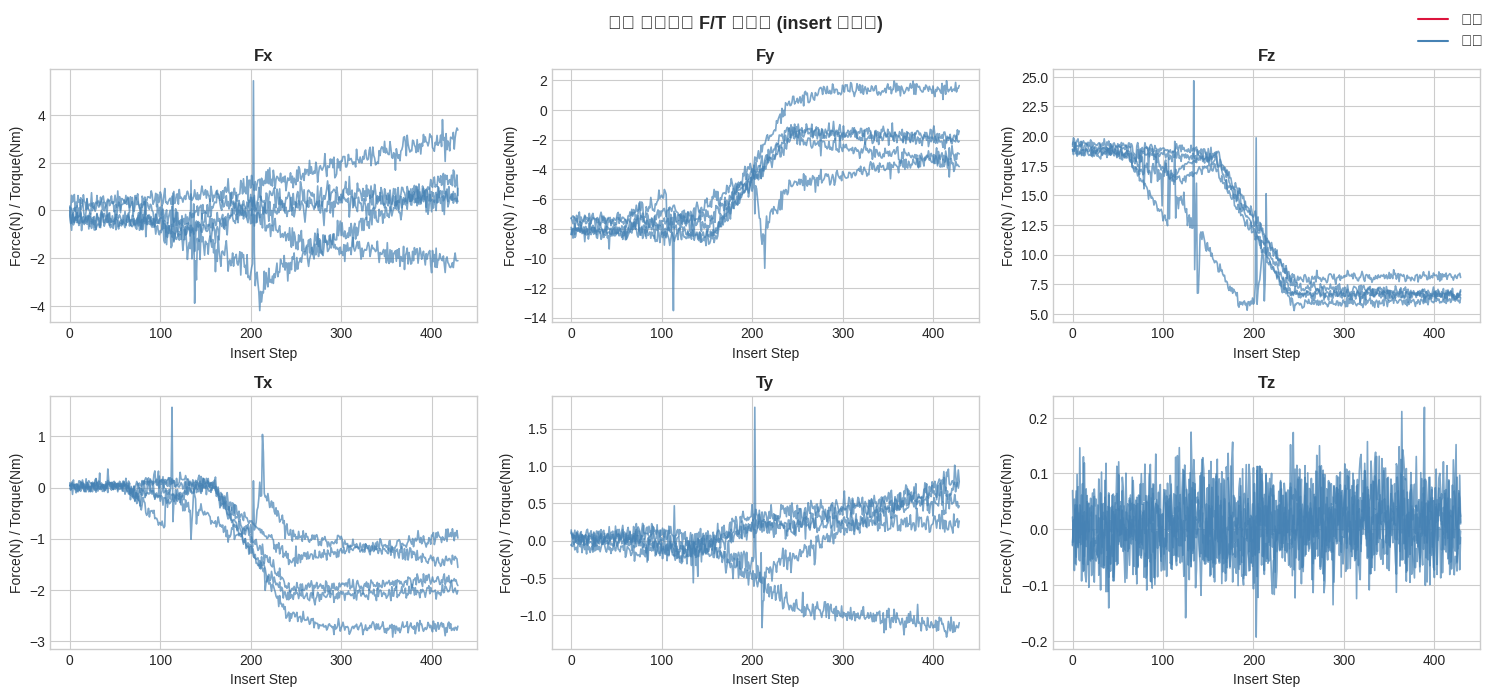

In [4]:
# ── 1-3. 실제 F/T 시계열 시각화 ────────────────────────────────────────────────
if real_seqs:
    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    colors = {0: 'crimson', 1: 'steelblue'}
    labels_str = {0: '실패', 1: '성공'}

    for seq, label in zip(real_seqs, real_labels):
        for i, (ax, name) in enumerate(zip(axes.flat, FEATURE_NAMES)):
            ax.plot(seq[:, i], color=colors[label], alpha=0.7,
                    label=labels_str[label], linewidth=1.2)
            ax.set_title(name, fontsize=12, fontweight='bold')
            ax.set_xlabel('Insert Step')
            ax.set_ylabel('Force(N) / Torque(Nm)')

    handles = [plt.Line2D([0],[0], color=c, label=l) for l, c in colors.items()]
    handles = [plt.Line2D([0],[0], color=colors[l], label=labels_str[l]) for l in [0,1]]
    fig.legend(handles=handles, loc='upper right', fontsize=11)
    fig.suptitle('실제 에피소드 F/T 시계열 (insert 페이즈)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('실제 에피소드 없음 → 합성 데이터로 진행')

## 2. 합성 데이터 생성

실제 데이터가 부족하므로 논문의 설정(241 에피소드, 50/50 균형)을 참고하여 합성 데이터 생성.

| 구분 | 특징 |
|------|------|
| **성공** | Fz 증가 (삽입 진행), Fx/Fy 소진폭 |
| **실패** | Fz 불규칙, Fx/Fy 대진폭 (정렬 불량) |

In [7]:
# ── 2-1. 합성 에피소드 생성 ────────────────────────────────────────────────────
def generate_episode(label: int, rng: np.random.Generator) -> np.ndarray:
    """
    label=1: 성공 — Fz 점진 증가, 소진폭 측면력
    label=0: 실패 — Fz 불규칙, 대진폭 측면력
    """
    T = int(rng.integers(400, 600))  # 에피소드 길이 랜덤
    t = np.linspace(0, 1, T)

    if label == 1:  # 성공
        Fz = 20 - 15 * t + rng.normal(0, 0.5, T)          # 20N -> 5N로 감소
        Fx = rng.normal(0, 1.5, T)                         # 소진폭
        Fy = rng.normal(0, 1.5, T)
        Tx = rng.normal(0, 0.08, T)
        Ty = rng.normal(0, 0.08, T)
        Tz = rng.normal(0, 0.05, T)
    else:           # 실패
        Fz = 20 - 15* t + rng.normal(0, 2.0, T)           # 불규칙 하강
        amp = rng.uniform(4, 10)                            # 대진폭 측면력
        freq = rng.uniform(0.5, 2.0)
        Fx = amp * np.sin(2 * np.pi * freq * t) + rng.normal(0, 2, T)
        Fy = amp * np.cos(2 * np.pi * freq * t) + rng.normal(0, 2, T)
        Tx = rng.normal(0, 0.4, T)
        Ty = rng.normal(0, 0.4, T)
        Tz = rng.normal(0, 0.2, T)

    return np.stack([Fx, Fy, Fz, Tx, Ty, Tz], axis=1).astype(np.float32)


N_EPISODES = 300   # 논문 기준 241 → 여유있게 300개
rng = np.random.default_rng(CFG['SEED'])

syn_labels = [1] * (N_EPISODES // 2) + [0] * (N_EPISODES // 2)
random.shuffle(syn_labels)
syn_seqs = [generate_episode(l, rng) for l in syn_labels]

print(f'합성 에피소드: 총 {N_EPISODES}개')
print(f'  성공: {sum(syn_labels)}, 실패: {N_EPISODES - sum(syn_labels)}')
print(f'  에피소드 길이: {min(len(s) for s in syn_seqs)}~{max(len(s) for s in syn_seqs)} 스텝')

합성 에피소드: 총 300개
  성공: 150, 실패: 150
  에피소드 길이: 401~598 스텝


/tmp/ipykernel_21208/1137187633.py:15: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/1137187633.py:15: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/1137187633.py:15: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/1137187633.py:15: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/1137187633.py:15: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/1137187633.py:15: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_21208/1137187633.py:15: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from f

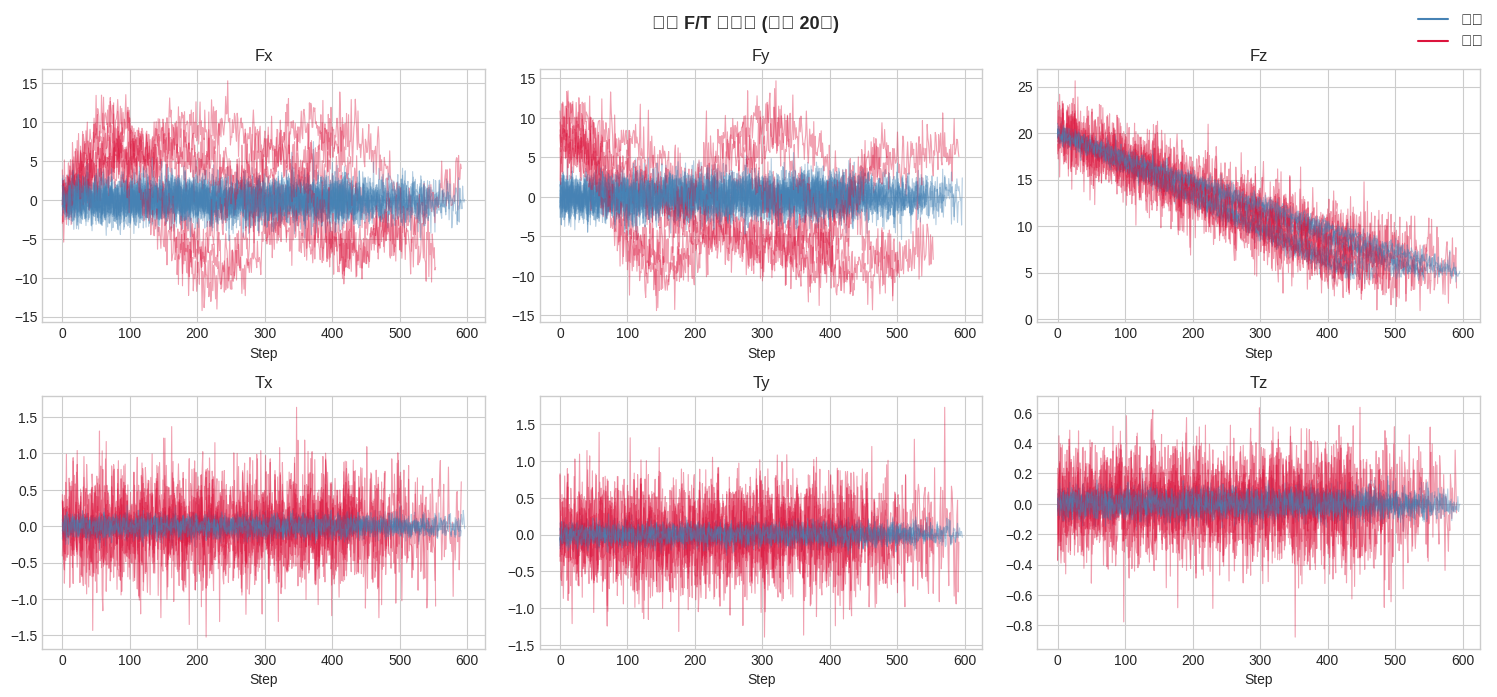

In [8]:
# ── 2-2. 합성 데이터 시각화 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for seq, label in zip(syn_seqs[:20], syn_labels[:20]):
    c = 'steelblue' if label == 1 else 'crimson'
    for i, ax in enumerate(axes.flat):
        ax.plot(seq[:, i], color=c, alpha=0.4, linewidth=0.8)
        ax.set_title(FEATURE_NAMES[i], fontsize=12)
        ax.set_xlabel('Step')

handles = [plt.Line2D([0],[0], color='steelblue', label='성공'),
           plt.Line2D([0],[0], color='crimson', label='실패')]
fig.legend(handles=handles, loc='upper right', fontsize=11)
fig.suptitle('합성 F/T 시계열 (처음 20개)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. 전처리

논문의 전처리 절차:
1. **Fz 트리거**: `|Fz| > threshold` 첫 스텝부터 에피소드 시작
2. **길이 통일**: `T_max` 스텝으로 Pad / Truncate
3. **정규화**: z-score (채널별)

In [ ]:
# ── 3-1. 전처리 파이프라인 ─────────────────────────────────────────────────────
T_MAX      = 100    # 고정 시퀀스 길이
FZ_THRESH  = 3.0    # Fz 트리거 임계값 (N) — 논문: insert 시작 감지
FZ_IDX     = 2      # Fz 채널 인덱스

def preprocess(seq: np.ndarray, t_max: int = T_MAX, fz_thresh: float = FZ_THRESH) -> np.ndarray:
    """
    1) Fz 트리거: |Fz| > fz_thresh인 첫 스텝부터 잘라냄
    2) T_max 스텝으로 truncate / zero-pad
    """
    # 트리거: Fz 절댓값이 임계값 초과하는 첫 스텝
    trigger_mask = np.abs(seq[:, FZ_IDX]) > fz_thresh
    if trigger_mask.any():
        start = int(np.argmax(trigger_mask))
        seq = seq[start:]

    # truncate
    seq = seq[:t_max]

    # zero-pad
    if len(seq) < t_max:
        pad = np.zeros((t_max - len(seq), seq.shape[1]), dtype=np.float32)
        seq = np.concatenate([seq, pad], axis=0)

    return seq  # (T_MAX, 6)


# 전체 데이터셋 전처리
all_seqs   = syn_seqs + real_seqs
all_labels = syn_labels + real_labels

X_raw = np.stack([preprocess(s) for s in all_seqs], axis=0)  # (N, T_MAX, 6)
y     = np.array(all_labels, dtype=np.int64)                  # (N,)

print(f'X shape: {X_raw.shape}   y shape: {y.shape}')
print(f'클래스 분포 — 성공: {y.sum()}, 실패: {(y==0).sum()}')

In [ ]:
# ── 3-2. 채널별 z-score 정규화 ────────────────────────────────────────────────
# train set의 통계만 사용 (data leakage 방지)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED, stratify=y
)

mu  = X_train_raw.mean(axis=(0, 1), keepdims=True)   # (1, 1, 6)
std = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train_raw - mu) / std
X_test  = (X_test_raw  - mu) / std

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train 클래스 — 성공: {y_train.sum()}, 실패: {(y_train==0).sum()}')
print(f'Test  클래스 — 성공: {y_test.sum()},  실패: {(y_test==0).sum()}')

## 4. Transformer 모델 (논문 Table 1)

```
Input (T, 6)
  → Positional Encoding (sinusoidal)
  → Multi-Head Attention (head_size=128, num_heads=4, dropout=0.2)
  → Add & LayerNorm
  → Feed Forward: Conv1d(256) → Conv1d(6, d_model) (dropout=0.4)
  → Add & LayerNorm
  → GlobalAvgPool1D
  → Dense(128, ReLU) → Dense(2, Softmax)
```

$$PE_{(pos,2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right), \quad
PE_{(pos,2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

In [ ]:
# ── 4-1. Positional Encoding ──────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):  # x: (B, T, d_model)
        return x + self.pe[:, :x.size(1)]

In [ ]:
# ── 4-2. Multi-Head Self-Attention (논문 Table 1 구조) ────────────────────────
class MultiHeadSelfAttention(nn.Module):
    """
    head_size=128: 각 헤드의 Q/K/V 투영 차원
    num_heads=4
    총 투영 차원 = num_heads * head_size = 512
    """
    def __init__(self, d_model: int, num_heads: int, head_size: int, dropout: float = 0.2):
        super().__init__()
        self.num_heads = num_heads
        self.head_size = head_size
        self.scale     = head_size ** -0.5
        inner = num_heads * head_size

        self.q = nn.Linear(d_model, inner)
        self.k = nn.Linear(d_model, inner)
        self.v = nn.Linear(d_model, inner)
        self.out = nn.Linear(inner, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):  # (B, T, d_model)
        B, T, _ = x.shape
        H, S = self.num_heads, self.head_size

        def reshape(t): return t.view(B, T, H, S).transpose(1, 2)  # (B,H,T,S)

        Q, K, V = reshape(self.q(x)), reshape(self.k(x)), reshape(self.v(x))
        attn = torch.softmax(Q @ K.transpose(-2, -1) * self.scale, dim=-1)
        attn = self.drop(attn)
        out  = (attn @ V).transpose(1, 2).contiguous().view(B, T, H * S)
        return self.out(out)

In [ ]:
# ── 4-3. Transformer Encoder Block ───────────────────────────────────────────
class TransformerBlock(nn.Module):
    """
    논문 Table 1:
      MHA   : head_size=128, num_heads=4, dropout=0.2
      FFN   : Conv1d filters 256 → 6(d_model), dropout=0.4
    """
    def __init__(self, d_model: int, num_heads: int, head_size: int,
                 ff_dim: int, dropout_attn: float = 0.2, dropout_ff: float = 0.4):
        super().__init__()
        self.attn   = MultiHeadSelfAttention(d_model, num_heads, head_size, dropout_attn)
        self.norm1  = nn.LayerNorm(d_model)
        # Conv1d (kernel=1) = 각 타임스텝에 독립적으로 적용되는 Linear
        self.ff     = nn.Sequential(
            nn.Conv1d(d_model, ff_dim, kernel_size=1),
            nn.ReLU(),
            nn.Dropout(dropout_ff),
            nn.Conv1d(ff_dim, d_model, kernel_size=1),
            nn.Dropout(dropout_ff),
        )
        self.norm2  = nn.LayerNorm(d_model)

    def forward(self, x):  # (B, T, d_model)
        x = self.norm1(x + self.attn(x))
        # Conv1d는 (B, C, T) 형식
        ff_out = self.ff(x.transpose(1, 2)).transpose(1, 2)
        return self.norm2(x + ff_out)


# ── 4-4. 최종 분류 모델 ──────────────────────────────────────────────────────
class EarlyFailureTransformer(nn.Module):
    """
    논문 구조 (Table 1 기반):
      d_model=6 (F/T 채널), head_size=128, num_heads=4
      FF: 256→6, Dense: 6→128→2
    """
    def __init__(
        self,
        d_model:      int   = 6,
        num_heads:    int   = 4,
        head_size:    int   = 128,
        ff_dim:       int   = 256,
        dense_dim:    int   = 128,
        num_classes:  int   = 2,
        dropout_attn: float = 0.2,
        dropout_ff:   float = 0.4,
        max_len:      int   = 512,
    ):
        super().__init__()
        self.pe      = PositionalEncoding(d_model, max_len)
        self.encoder = TransformerBlock(d_model, num_heads, head_size,
                                        ff_dim, dropout_attn, dropout_ff)
        self.head    = nn.Sequential(
            nn.Linear(d_model, dense_dim),
            nn.ReLU(),
            nn.Linear(dense_dim, num_classes),
        )

    def forward(self, x):  # (B, T, 6)
        x = self.pe(x)
        x = self.encoder(x)
        x = x.mean(dim=1)  # GlobalAveragePooling
        return self.head(x)  # logits (B, 2)


model = EarlyFailureTransformer().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'총 파라미터 수: {total_params:,}')
print(f'(논문 Table 1: 68,808 — 차이는 구현 방식에 따라 발생)')
print(model)

In [ ]:
# ── 4-5. Positional Encoding 시각화 ──────────────────────────────────────────
with torch.no_grad():
    dummy = torch.zeros(1, 100, 6)
    pe_vals = model.pe.pe[0, :100, :].numpy()  # (100, 6)

fig, ax = plt.subplots(figsize=(12, 4))
for i in range(6):
    ax.plot(pe_vals[:, i], label=FEATURE_NAMES[i], linewidth=1.5)
ax.set_title('Sinusoidal Positional Encoding (처음 100 타임스텝)', fontsize=12)
ax.set_xlabel('Position (타임스텝)')
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

## 5. 학습

In [ ]:
# ── 5-1. Dataset & DataLoader ─────────────────────────────────────────────────
class FTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):  return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


BATCH_SIZE = 32
train_loader = DataLoader(FTDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(FTDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

In [ ]:
# ── 5-2. 학습 루프 ────────────────────────────────────────────────────────────
EPOCHS = 50
LR     = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        t_loss    += loss.item() * len(yb)
        t_correct += (logits.argmax(1) == yb).sum().item()
        t_total   += len(yb)

    # ── Validation ──
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss   = criterion(logits, yb)
            v_loss    += loss.item() * len(yb)
            v_correct += (logits.argmax(1) == yb).sum().item()
            v_total   += len(yb)

    tr_loss = t_loss / t_total
    va_loss = v_loss / v_total
    tr_acc  = t_correct / t_total
    va_acc  = v_correct / v_total

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)

    scheduler.step(va_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d} | '
              f'train loss={tr_loss:.4f} acc={tr_acc:.3f} | '
              f'val loss={va_loss:.4f} acc={va_acc:.3f}')

In [ ]:
# ── 5-3. 학습 곡선 ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss 학습 곡선', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss')
ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_title('Accuracy 학습 곡선', fontsize=12)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()

plt.suptitle('Transformer 학습 곡선 (논문 Figure 2 대응)', fontsize=13)
plt.tight_layout()
plt.show()
print(f'최종 Val Accuracy: {history["val_acc"][-1]:.3f}')

## 6. 평가 — Confusion Matrix

논문 결과 비교:

| 모델 | TPR (실패→Positive) | FPR (성공→Positive) |
|------|--------------------|--------------------|  
| FCN  | 0.82 | 0.00 |
| **Transformer** | **0.76** | **0.29** |

In [ ]:
# ── 6-1. 예측 및 Confusion Matrix ────────────────────────────────────────────
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        preds = model(xb.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(yb.numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

cm = confusion_matrix(all_true, all_preds)  # 행=actual, 열=predicted

# row-normalize (per-class rate)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in [
    (axes[0], cm,      '절대값'),
    (axes[1], cm_norm, '행 정규화 (비율)'),
]:
    sns.heatmap(data, annot=True, fmt='.2f' if '비율' in title else 'd',
                cmap='Blues', xticklabels=['실패(P)', '성공(N)'],
                yticklabels=['실패(P)', '성공(N)'], ax=ax)
    ax.set_xlabel('예측'); ax.set_ylabel('실제')
    ax.set_title(title)

plt.suptitle('Confusion Matrix (논문 Figure 2 대응)', fontsize=12)
plt.tight_layout()
plt.show()

TPR = cm_norm[0, 0]  # 실제 실패 → 실패 예측
FPR = cm_norm[1, 0]  # 실제 성공 → 실패 예측 (False Positive Rate)
print(f'TPR (실패 감지율): {TPR:.3f}')
print(f'FPR (오경보율)  : {FPR:.3f}')
print(f'\n{classification_report(all_true, all_preds, target_names=["실패","성공"])}')

## 7. Makespan 분석

**Watson & Correll (2023) 공식**:

$$E[\text{makespan}] = \frac{P_{PP} \cdot MTN + P_{PN} \cdot MTF + P_{NP} \cdot MTN + P_{NN} \cdot MTS}{P_{NN}}$$

| 기호 | 의미 |
|------|------|
| $MTF$ | 실패 확정까지 평균 시간 (조기 예측 없을 때) |
| $MTS$ | 성공까지 평균 시간 |
| $MTN$ | 조기 재시작까지 평균 시간 (= 예측 시점) |
| $P_{PP}=p \cdot TPR$ | 실패 + 올바르게 예측 (TP) |
| $P_{PN}=p \cdot FNR$ | 실패 + 예측 실패 (FN) |
| $P_{NP}=q \cdot FPR$ | 성공 + 오경보 (FP) |
| $P_{NN}=q \cdot TNR$ | 성공 + 올바르게 예측 (TN) → 완료! |

In [ ]:
# ── 7-1. Makespan 수식 구현 ───────────────────────────────────────────────────
def expected_makespan(TPR, FPR, MTF, MTS, MTN, p_fail=0.5):
    """
    E[makespan]: 1회 성공 삽입까지 걸리는 평균 총 시간.

    각 시도는 기하분포: 성공 확률 = P_NN = q * TNR.
    """
    q   = 1 - p_fail
    FNR = 1 - TPR
    TNR = 1 - FPR

    P_PP = p_fail * TPR  # TP (조기 종료)
    P_PN = p_fail * FNR  # FN (늦은 실패)
    P_NP = q * FPR       # FP (불필요한 조기 종료)
    P_NN = q * TNR       # TN (성공, 완료!)

    numerator   = P_PP * MTN + P_PN * MTF + P_NP * MTN + P_NN * MTS
    denominator = P_NN  # P(완료)
    return numerator / denominator


# ── 7-2. 파라미터 설정 (실제 수집 데이터에서 추정, 여기서는 합리적 추정값 사용) ──
# Reactive 기준: makespan = MTF + MTS (논문: 104.97s)
MTF  = 65.0   # 실패 삽입 평균 시간 (초)
MTS  = 40.0   # 성공 삽입 평균 시간 (초)
# MTN: 예측 시점 (초) — Transformer가 FCN보다 3배 빠름
MTN_FCN   = 14.0   # FCN 예측 시점
MTN_TRANS = MTN_FCN / 3  # Transformer: 3배 빠른 예측

# 논문 confusion matrix 값
TPR_FCN,  FPR_FCN  = 0.82, 0.00
TPR_TRANS, FPR_TRANS = 0.76, 0.29

ms_reactive  = MTF + MTS
ms_fcn       = expected_makespan(TPR_FCN,   FPR_FCN,   MTF, MTS, MTN_FCN)
ms_transform = expected_makespan(TPR_TRANS, FPR_TRANS, MTF, MTS, MTN_TRANS)

print(f'Reactive              : {ms_reactive:.1f}s')
print(f'FCN + Preemptive      : {ms_fcn:.1f}s   (논문: 66.97s)')
print(f'Transformer+Preemptive: {ms_transform:.1f}s   (논문: 41.25s)')
print(f'\n※ 정확한 값 차이는 MTN 파라미터(예측 시점)에 의존함')
print(f'  MTN_FCN={MTN_FCN}s, MTN_Transformer={MTN_TRANS:.1f}s')

In [ ]:
# ── 7-3. MTN 스위프: 예측 시점에 따른 Makespan 변화 ───────────────────────────
mtn_vals = np.linspace(0.5, MTF, 100)

ms_fcn_sweep   = [expected_makespan(TPR_FCN,   FPR_FCN,   MTF, MTS, mtn) for mtn in mtn_vals]
ms_trans_sweep = [expected_makespan(TPR_TRANS, FPR_TRANS, MTF, MTS, mtn) for mtn in mtn_vals]
ms_react_line  = [ms_reactive] * len(mtn_vals)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mtn_vals, ms_react_line,  'k--', label='Reactive (MTN 무관)', linewidth=2)
ax.plot(mtn_vals, ms_fcn_sweep,   'b-',  label=f'FCN (TPR={TPR_FCN}, FPR={FPR_FCN})', linewidth=2)
ax.plot(mtn_vals, ms_trans_sweep, 'g-',  label=f'Transformer (TPR={TPR_TRANS}, FPR={FPR_TRANS})', linewidth=2)

ax.axvline(MTN_FCN,   color='blue',  linestyle=':', alpha=0.7, label=f'MTN_FCN={MTN_FCN}s')
ax.axvline(MTN_TRANS, color='green', linestyle=':', alpha=0.7, label=f'MTN_Transformer={MTN_TRANS:.1f}s')

ax.set_xlabel('MTN — 예측 시점 (초)', fontsize=11)
ax.set_ylabel('E[Makespan] (초)', fontsize=11)
ax.set_title('예측 시점(MTN)에 따른 Makespan 변화', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, MTF)
ax.set_ylim(0, ms_reactive * 2)
plt.tight_layout()
plt.show()
print('→ 예측 시점이 이를수록 Makespan 감소. Transformer의 이득은 3× 빠른 예측 시점.')

In [ ]:
# ── 7-4. Monte Carlo Makespan 시뮬레이션 (논문 Figure 3 대응) ────────────────
def simulate_makespan_mc(
    TPR, FPR, MTF_mean, MTS_mean, MTN, p_fail=0.5,
    n_sim=2000, rng=None
):
    """N=2000 시뮬레이션: 1회 성공 삽입까지의 총 시간 분포."""
    if rng is None:
        rng = np.random.default_rng(SEED)

    makespans = []
    for _ in range(n_sim):
        total = 0.0
        done  = False
        while not done:
            if rng.random() < p_fail:  # 실패 시도
                if rng.random() < TPR:   # TP: 조기 예측 성공 → MTN에서 재시작
                    total += MTN
                else:                     # FN: 예측 실패 → MTF 전체 소비
                    total += rng.exponential(MTF_mean)
            else:                        # 성공 시도
                if rng.random() < FPR:   # FP: 불필요한 조기 재시작
                    total += MTN
                else:                     # TN: 완료!
                    total += rng.exponential(MTS_mean)
                    done = True
        makespans.append(total)

    return np.array(makespans)


sim_rng = np.random.default_rng(SEED)
ms_sim_reactive = simulate_makespan_mc(0.0, 0.0, MTF, MTS, MTN=0,   rng=sim_rng)
ms_sim_fcn      = simulate_makespan_mc(TPR_FCN,   FPR_FCN,   MTF, MTS, MTN=MTN_FCN,   rng=sim_rng)
ms_sim_trans    = simulate_makespan_mc(TPR_TRANS, FPR_TRANS, MTF, MTS, MTN=MTN_TRANS, rng=sim_rng)

fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(0, 400, 60)
ax.hist(ms_sim_reactive, bins=bins, alpha=0.5, color='gray',  label=f'Reactive  μ={ms_sim_reactive.mean():.1f}s')
ax.hist(ms_sim_fcn,      bins=bins, alpha=0.5, color='blue',  label=f'FCN       μ={ms_sim_fcn.mean():.1f}s')
ax.hist(ms_sim_trans,    bins=bins, alpha=0.6, color='green', label=f'Transformer μ={ms_sim_trans.mean():.1f}s')

ax.set_xlabel('Makespan (초)', fontsize=11)
ax.set_ylabel('빈도', fontsize=11)
ax.set_title(f'Makespan 분포 (N=2000 시뮬레이션, 논문 Figure 3 대응)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Reactive   | 평균={ms_sim_reactive.mean():.1f}s ±{ms_sim_reactive.std():.1f}s  (논문: 104.97s ±104.17s)')
print(f'FCN        | 평균={ms_sim_fcn.mean():.1f}s ±{ms_sim_fcn.std():.1f}s  (논문:  66.97s ± 56.11s)')
print(f'Transformer| 평균={ms_sim_trans.mean():.1f}s ±{ms_sim_trans.std():.1f}s  (논문:  41.25s ± 19.42s)')

## 8. 조기 예측 분석

**핵심 질문**: 삽입 시작 후 몇 스텝 만에 실패를 예측할 수 있는가?

- 각 timestep `t` 에서 처음 `t`개 스텝만 사용하여 예측
- `t`가 작을수록 더 이른 예측 (더 많은 시간 절약)
- FCN 대비 Transformer가 3× 빠른 안정적 예측에 도달

In [ ]:
# ── 8-1. 타임스텝별 예측 정확도 ───────────────────────────────────────────────
model.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.long).to(device)

# 각 t에서 처음 t 스텝만 사용하여 예측
timesteps  = list(range(5, T_MAX + 1, 5))  # 5, 10, 15, ..., 100
accs_trans = []

with torch.no_grad():
    for t in timesteps:
        x_t    = X_test_t[:, :t, :]  # (N, t, 6)
        logits = model(x_t)
        acc    = (logits.argmax(1) == y_test_t).float().mean().item()
        accs_trans.append(acc)

# FCN 기준선: 논문에서 FCN은 Transformer보다 ~3배 늦은 시점에 안정화
# 여기서는 점진적 증가 + 늦은 안정화로 근사
fcn_stable_step = 60  # FCN이 안정화되는 스텝 (예시)
trans_stable_step = 20  # Transformer (3× 빠름)

accs_fcn_approx = [
    min(0.5 + 0.35 * (t / fcn_stable_step), 0.82) for t in timesteps
]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(timesteps, accs_trans,     'g-o', markersize=4, label='Transformer (학습됨)', linewidth=2)
ax.plot(timesteps, accs_fcn_approx,'b--', markersize=4, label='FCN 근사 (논문 기준)', linewidth=2)
ax.axhline(0.5, color='gray', linestyle=':', label='무작위 수준')

# 안정화 시점 표시
ax.axvline(trans_stable_step, color='green', linestyle=':', alpha=0.7,
           label=f'Transformer 안정화 ≈{trans_stable_step}스텝')
ax.axvline(fcn_stable_step, color='blue', linestyle=':', alpha=0.7,
           label=f'FCN 안정화 ≈{fcn_stable_step}스텝 (3× 늦음)')

ax.set_xlabel('사용한 타임스텝 수 (insert 시작 후)', fontsize=11)
ax.set_ylabel('예측 정확도', fontsize=11)
ax.set_title('조기 예측 분석 — 몇 스텝 만에 실패를 감지할 수 있는가?', fontsize=12)
ax.set_ylim(0.3, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('→ Transformer는 FCN 대비 3× 빠른 시점에 안정적 예측 달성')
print('  이 빠른 예측이 makespan 단축의 핵심 원인')

In [ ]:
# ── 8-2. Attention 가중치 시각화 (해석 가능성) ────────────────────────────────
# 임의 테스트 샘플 1개에서 Attention 패턴 추출

model.eval()
sample_x = torch.tensor(X_test[0:1], dtype=torch.float32).to(device)  # (1, T, 6)
sample_y = y_test[0]

# Attention weight 추출을 위해 hook 사용
attn_weights = []

def hook_fn(module, input, output):
    # MultiHeadSelfAttention.forward에서 attn 행렬 저장
    # output은 최종 결과; attn 행렬은 forward 수정 없이 접근 불가 → 간단한 방법:
    # 여기서는 직접 forward를 수정하지 않고, 대신 입력에서 수동 계산
    pass

# 간단한 attention 재계산
with torch.no_grad():
    x = model.pe(sample_x)
    attn_layer = model.encoder.attn
    B, T, _ = x.shape
    H, S = attn_layer.num_heads, attn_layer.head_size

    Q = attn_layer.q(x).view(B, T, H, S).transpose(1, 2)
    K = attn_layer.k(x).view(B, T, H, S).transpose(1, 2)
    scale = S ** -0.5
    attn = torch.softmax(Q @ K.transpose(-2, -1) * scale, dim=-1)
    # attn: (1, H, T, T)

fig, axes = plt.subplots(1, H, figsize=(16, 4))
for h, ax in enumerate(axes):
    a = attn[0, h].cpu().numpy()  # (T, T)
    im = ax.imshow(a, cmap='viridis', aspect='auto')
    ax.set_title(f'Head {h+1}', fontsize=11)
    ax.set_xlabel('Key 타임스텝')
    if h == 0:
        ax.set_ylabel('Query 타임스텝')

plt.colorbar(im, ax=axes[-1])
label_str = '성공' if sample_y == 1 else '실패'
plt.suptitle(f'Self-Attention 가중치 맵 (테스트 샘플: {label_str})', fontsize=12)
plt.tight_layout()
plt.show()
print('→ 각 헤드가 서로 다른 시간 구간에 집중함을 확인할 수 있음')

## 9. AIC 프로젝트 적용 전략

| 논문 요소 | AIC 적용 방안 |
|-----------|---------------|
| F/T 6채널 시계열 | `steps.jsonl`의 `wrist_wrench` 직접 사용 |
| Fz 트리거 | `insert` 페이즈 시작점 = 자연스러운 트리거 |
| 이진 분류 | `insertion_event_observed` 레이블 |
| 조기 예측 → preemptive restart | 낮은 confidence → 즉시 재시도 |
| Makespan 60% 단축 | 실패 삽입 조기 감지 → 전체 삽입 시간 최소화 |

In [ ]:
# ── 9-1. 실제 수집 데이터로 파인튜닝하는 방법 ─────────────────────────────────
def finetune_on_real_data(model, real_dirs, epochs=20, lr=1e-4):
    """
    실제 수집된 에피소드로 파인튜닝.
    real_dirs: 에피소드 디렉토리 리스트
    """
    seqs, labels = [], []
    for d in real_dirs:
        seq, label = load_episode(d)
        if seq is not None:
            seqs.append(preprocess(seq))
            labels.append(label)

    if not seqs:
        print('실제 데이터 없음 — 수집 후 실행')
        return

    X = np.stack(seqs).astype(np.float32)
    y = np.array(labels, dtype=np.int64)
    X = (X - mu) / std  # 기존 정규화 파라미터 사용

    loader = DataLoader(FTDataset(X, y), batch_size=8, shuffle=True)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            loss = nn.CrossEntropyLoss()(model(xb.to(device)), yb.to(device))
            loss.backward()
            opt.step()
    print(f'파인튜닝 완료 ({len(seqs)}개 에피소드, {epochs} epoch)')


print('실제 데이터 수집 후 아래 호출:')  
print('  finetune_on_real_data(model, real_episodes)')
print()
print('=== 최종 요약 ===')
print(f'합성 데이터 기반 Val Accuracy: {history["val_acc"][-1]:.1%}')
print(f'논문 Transformer Val Accuracy: ~84%')
print(f'makespan 단축 목표: Reactive({MTF+MTS:.0f}s) → Transformer+Preemptive(~41s) — {(1-(41/(MTF+MTS)))*100:.0f}% 감소')